# Online Retail

- InvoiceNo	ID	Categorical	a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation
- StockCode	ID	Categorical	a 5-digit integral number uniquely assigned to each distinct product
- Description	Feature	Categorical	product name
- Quantity	Feature	Integer	the quantities of each product - (item) per transaction
- InvoiceDate	Feature	Date	the day and time when each - transaction was generated
- UnitPrice	Feature	Continuous	product price per unit	sterling
- CustomerID	Feature	Categorical	a 5-digit integral number - uniquely assigned to each customer
- Country	Feature	Categorical	the name of the country where each customer resides

In [95]:
import numpy as np
import pandas as pd 

# Ignorar avisos irrelevantes
import warnings
warnings.filterwarnings("ignore")

In [96]:
df = pd.read_excel("OnlineRetail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [97]:
df.shape

(541909, 8)

In [98]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Investigámos a existencia de valores nulos.

In [99]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [100]:
df = df.dropna(subset=['CustomerID'])
print(df.shape)

(406829, 8)


In [101]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

ver duplicados

In [102]:
df.duplicated().sum()

5225

In [103]:
duplicados = df[df.duplicated(keep=False)]

duplicados_ordenados = duplicados.sort_values(by=['InvoiceNo', 'StockCode', 'Quantity'])

duplicados_ordenados.head(12)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [104]:
df = df.drop_duplicates()
print(df.shape)

(401604, 8)


Investigar se os stockcodes correspondiam sempre à mesma description

In [105]:
df.groupby('StockCode')['Description'].nunique()[lambda x: x > 1]

StockCode
20622     2
20725     2
20914     2
21109     2
21112     2
         ..
85184C    2
85185B    2
90014A    2
90014B    2
90014C    2
Name: Description, Length: 213, dtype: int64

Fomos ver individualmente o que estava a acontecer e notou-se um padrão. Mas que eram necessariamente os mesmos produtos.

In [106]:
df[df['StockCode'].astype(str) == '21112']['Description'].unique()

array(['SWISS ROLL TOWEL, PINK  SPOTS', 'SWISS ROLL TOWEL PINK  SPOTS'],
      dtype=object)

In [107]:
df[df['StockCode'].astype(str) == '21175']['Description'].unique()

array(['GIN + TONIC DIET METAL SIGN', 'GIN AND TONIC DIET METAL SIGN'],
      dtype=object)

In [108]:
df[df['StockCode'].astype(str) == '21232']['Description'].unique()

array(['STRAWBERRY CERAMIC TRINKET BOX', 'STRAWBERRY CERAMIC TRINKET POT'],
      dtype=object)

In [109]:
df[df['StockCode'].astype(str) == '85185B']['Description'].unique()

array(['PINK HORSE SOCK PUPPET', 'PINK HORSE SOCK PUPPET KIT'],
      dtype=object)

## Limpar as variáveis numéricas que estavam como objeto

Observar os casos de StockCode que não estão numéricos.

In [110]:
df[~df['StockCode'].astype(str).str.isnumeric()]['StockCode'].value_counts()


StockCode
85123A    2065
85099B    1659
POST      1196
82494L     832
85099C     670
          ... 
90214O       1
90214T       1
90214U       1
90214W       1
90214Z       1
Name: count, Length: 886, dtype: int64

Investigar um caso concreto

In [111]:
df[df['StockCode'].astype(str).str.startswith('90214')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2423,536591,90214M,"LETTER ""M"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom
2424,536591,90214V,"LETTER ""V"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom
2425,536591,90214S,"LETTER ""S"" BLING KEY RING",1,2010-12-01 16:57:00,1.25,14606.0,United Kingdom
2426,536591,90214J,"LETTER ""J"" BLING KEY RING",2,2010-12-01 16:57:00,1.25,14606.0,United Kingdom
17499,537765,90214S,"LETTER ""S"" BLING KEY RING",2,2010-12-08 12:08:00,1.25,14606.0,United Kingdom


Investigar outro caso

In [112]:
df[df['StockCode'].astype(str).str.startswith('85123')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
49,536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:02:00,2.55,17850.0,United Kingdom
66,536375,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:32:00,2.55,17850.0,United Kingdom
220,536390,85123A,WHITE HANGING HEART T-LIGHT HOLDER,64,2010-12-01 10:19:00,2.55,17511.0,United Kingdom
262,536394,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,2010-12-01 10:39:00,2.55,13408.0,United Kingdom


Eliminar o que estiver à frente dos 5 digitos

In [113]:
df['StockCode'] = df['StockCode'].astype(str).str[:5]

Ver se ainda há letras ou símbolos no stockcode.

In [114]:
df[~df['StockCode'].astype(str).str.isnumeric()]['StockCode'].value_counts()

StockCode
POST     1196
M         460
C2        134
D          77
DOT        16
CRUK       16
BANK       12
PADS        4
Name: count, dtype: int64

Eliminar o que restava e passar a variável para numérica.

In [115]:
df = df[df['StockCode'].astype(str).str.isnumeric()]
df['StockCode'] = df['StockCode'].astype(int)

Ver se tudo parece bater certo.

In [116]:
df.sort_values('StockCode').head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
75792,542610,10002,INFLATABLE POLITICAL GLOBE,14,2011-01-30 14:05:00,0.85,13148.0,United Kingdom
59184,541277,10002,INFLATABLE POLITICAL GLOBE,1,2011-01-17 11:46:00,0.85,12673.0,Germany
22380,538167,10002,INFLATABLE POLITICAL GLOBE,12,2010-12-09 18:58:00,0.85,14713.0,United Kingdom
21551,538093,10002,INFLATABLE POLITICAL GLOBE,12,2010-12-09 14:49:00,0.85,12682.0,France
20617,538069,10002,INFLATABLE POLITICAL GLOBE,8,2010-12-09 14:08:00,0.85,16795.0,United Kingdom


Ver o resultado final.

In [117]:
df.info()

<class 'pandas.DataFrame'>
Index: 399689 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    399689 non-null  object        
 1   StockCode    399689 non-null  int32         
 2   Description  399689 non-null  object        
 3   Quantity     399689 non-null  int64         
 4   InvoiceDate  399689 non-null  datetime64[us]
 5   UnitPrice    399689 non-null  float64       
 6   CustomerID   399689 non-null  float64       
 7   Country      399689 non-null  str           
dtypes: datetime64[us](1), float64(2), int32(1), int64(1), object(2), str(1)
memory usage: 31.0+ MB


Viu-se que o InvoiceNo também ainda está como objeto e deve ser portando tratado.

Observar os casos de InvoiceNo que não estão numéricos.

In [118]:
df[~df['InvoiceNo'].astype(str).str.isnumeric()]['InvoiceNo'].value_counts()

InvoiceNo
C570867    101
C560540     57
C548460     45
C560855     40
C570828     39
          ... 
C581393      1
C581463      1
C581470      1
C581484      1
C581568      1
Name: count, Length: 3383, dtype: int64

Eliminar as compras que foram canceladas

In [119]:
df = df[df['StockCode'].astype(str).str.isnumeric()]
df['StockCode'] = df['StockCode'].astype(int)

Ver o resultado final.

In [120]:
df.info()

<class 'pandas.DataFrame'>
Index: 399689 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    399689 non-null  object        
 1   StockCode    399689 non-null  int32         
 2   Description  399689 non-null  object        
 3   Quantity     399689 non-null  int64         
 4   InvoiceDate  399689 non-null  datetime64[us]
 5   UnitPrice    399689 non-null  float64       
 6   CustomerID   399689 non-null  float64       
 7   Country      399689 non-null  str           
dtypes: datetime64[us](1), float64(2), int32(1), int64(1), object(2), str(1)
memory usage: 31.0+ MB


In [121]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


observar numéricas estatisticamente

In [122]:
df.describe()

,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID
count,399689.000000,399689.000000,399689,399689.000000,399689.000000
mean,30779.451949,12.229383,2011-07-10 12:35:13.693046,2.907457,15288.696411
min,10002.000000,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,22029.000000,2.000000,2011-04-06 15:02:00,1.250000,13959.000000
50%,22666.000000,5.000000,2011-07-29 15:51:00,1.950000,15152.000000
75%,23268.000000,12.000000,2011-10-20 12:03:00,3.750000,16791.000000
max,90214.000000,80995.000000,2011-12-09 12:50:00,649.500000,18287.000000
std,20621.487819,250.836859,NaN,4.451881,1710.810771


In [123]:
# Remover quantidades e preços inválidos
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [124]:
df.sort_values('Quantity', ascending=False).head(10)



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754.0,United Kingdom


como há vários valores grandes de quantity pode ser normal, podem fazer também fornecimento a lojas.

In [125]:
df.sort_values('UnitPrice', ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5,15098.0,United Kingdom
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5,15098.0,United Kingdom
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.0,13145.0,United Kingdom
133994,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-25 14:19:00,295.0,13452.0,United Kingdom
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16 08:41:00,295.0,16607.0,United Kingdom
171178,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-04-28 12:22:00,295.0,14973.0,United Kingdom
118769,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-14 11:38:00,295.0,13452.0,United Kingdom
82768,543253,22655,VINTAGE RED KITCHEN CABINET,1,2011-02-04 15:32:00,295.0,14842.0,United Kingdom
205759,554836,22655,VINTAGE RED KITCHEN CABINET,1,2011-05-26 16:25:00,295.0,13015.0,United Kingdom
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,2011-01-10 14:57:00,295.0,17406.0,United Kingdom


Faz sentido os valores mais altos tendo em conta o que são.

## Coluna revenue

Criámos uma coluna chamada revenue quem tem em conta quanto essas pessoas estão dispostas a pagar por esses produtos, o que poderá ser útil.

In [126]:
# Criar coluna Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [127]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### Eliminar coluna descrição
Tirou-se a descrição já que alguns algoritmos não podem ter variáveis string.

In [128]:
# Descartar colunas desnecessárias
df_semdesc = df.drop(columns=['Description'])

## EDA

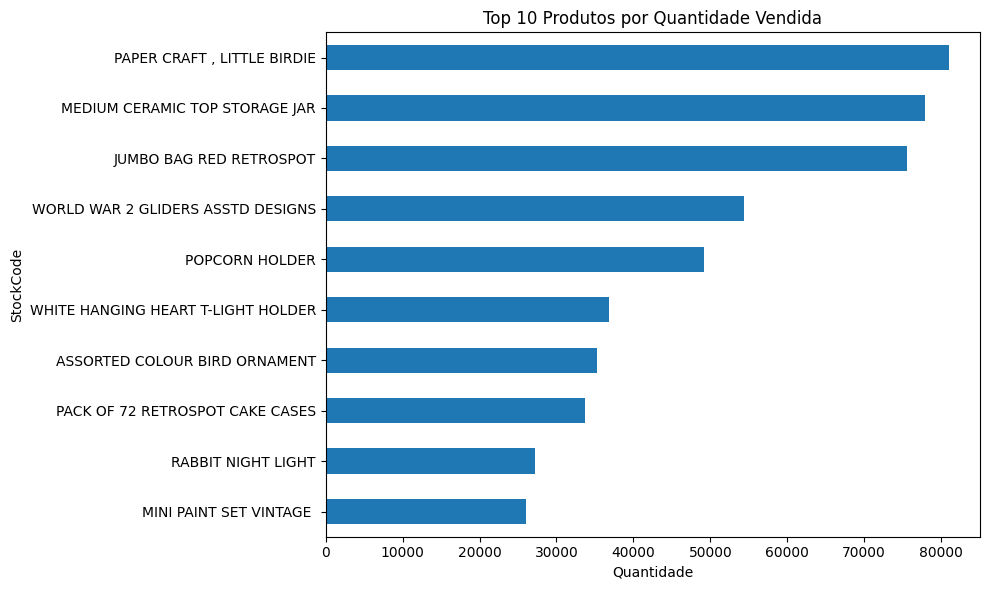

In [129]:
import matplotlib.pyplot as plt
# Top 10 produtos por quantidade vendida
top_qty = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).head(10)
desc_map = df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])
top_qty.index = top_qty.index.map(desc_map)
top_qty.sort_values().plot(kind='barh', figsize=(10, 6), title='Top 10 Produtos por Quantidade Vendida')
plt.xlabel('Quantidade')
plt.tight_layout(); plt.show()

Vimos os produtos que provavelmente serão os mais relevantes e itens frequentes no à priori.

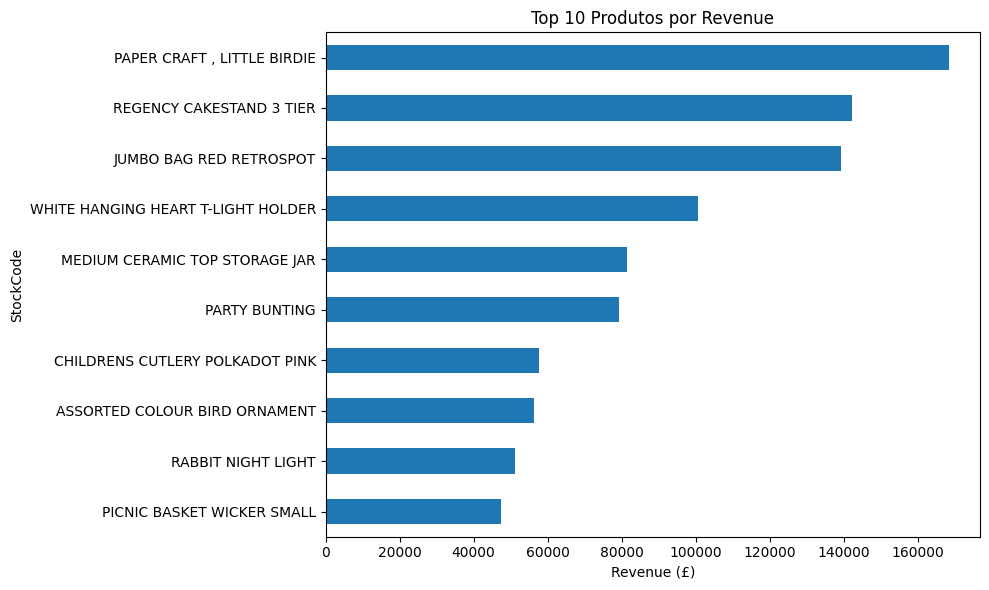

In [130]:
# Top 10 produtos por revenue
top_products = df.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False).head(10)
desc_map = df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0])
top_products.index = top_products.index.map(desc_map)
top_products.sort_values().plot(kind='barh', figsize=(10, 6), title='Top 10 Produtos por Revenue')
plt.xlabel('Revenue (£)')
plt.tight_layout(); plt.show()

Interessantemente os produtos que dão à loja mais revenue e que nos poderão ser úteis são também em maioria os mais vendidos. Exceto o regency cakestand 3 tier apesar de não ser do top mais vendido devido ao seu preço dá mais revenue à loja. 

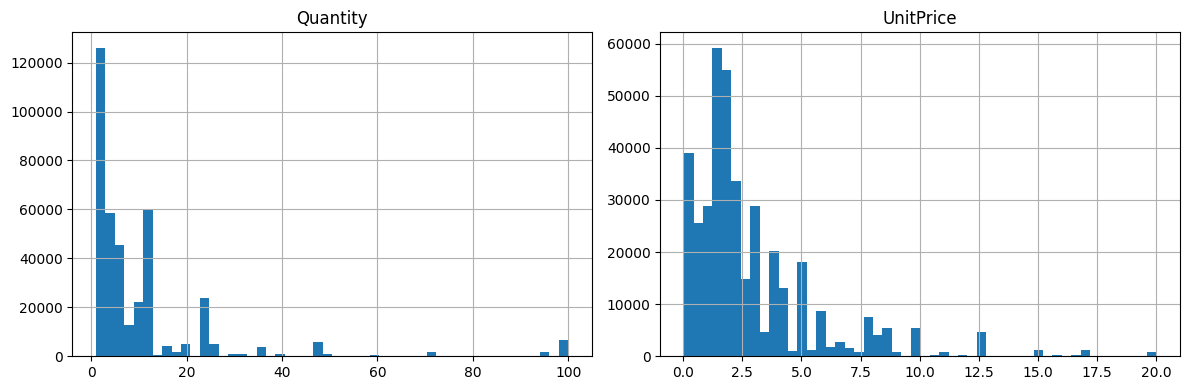

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Quantity'].clip(upper=100).hist(bins=50, ax=axes[0])
axes[0].set_title('Quantity')
df['UnitPrice'].clip(upper=20).hist(bins=50, ax=axes[1])
axes[1].set_title('UnitPrice')
plt.tight_layout(); plt.show()

Com estes gráficos vemos que a maioria dos nossos produtos têm preços baixos e são vendidos também em poucas quantidades.

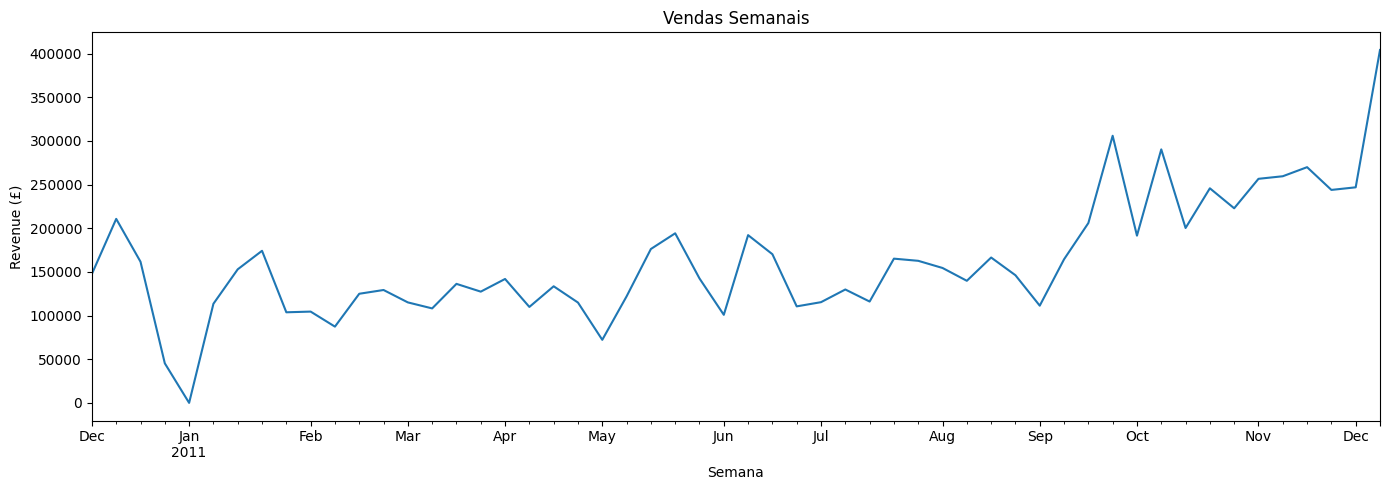

In [132]:
# Vendas semanais
vendas_semanal = df.set_index('InvoiceDate').resample('W')['Revenue'].sum()
vendas_semanal.plot(kind='line', figsize=(14, 5), title='Vendas Semanais')
plt.xlabel('Semana')
plt.ylabel('Revenue (£)')
plt.tight_layout(); plt.show()

Com este gráfico vemos as "seasons" picos de venda que como podemos perceber parecem ser as datas perto do Natal.

In [133]:
import plotly.express as px

# Vendas por mês
df['Month-Year'] = df['InvoiceDate'].dt.strftime('%m-%Y')
vendas_mes = df.groupby('Month-Year')['Revenue'].sum().reset_index()
vendas_mes = vendas_mes.sort_values('Month-Year')

fig = px.bar(vendas_mes, x='Month-Year', y='Revenue',
             color='Revenue',
             labels={'Revenue': 'Revenue (£)', 'Month-Year': 'Mês'},
             title='Vendas Mensais')

fig.update_layout(width=900, height=500)
fig.show()


Novamente vemos picos claros, possivelmente nas vendas de natal, que já era o que esperávamos.

## Tratar as datas
Para tratar as datas e torná-las variáveis numéricas criámos 2 variáveis novas. A primeira é os dias a partir da primeira venda em conta a diferença temporal do inicio até ao dia. Também para que o modelo possa permitir sazonalidade, que como vimos era importante, mantemos uma variável month- isto também faz sentido já que produtos diferentes são mais ou menos vendidos em alturas diferentes, exemplo guarda-chuvas.

In [134]:
reference_date = df_semdesc['InvoiceDate'].min()
df_semdesc['DaysSinceStart'] = (df_semdesc['InvoiceDate'] - reference_date).dt.days
df_semdesc['Month'] = df_semdesc['InvoiceDate'].dt.month
df_semdesc = df_semdesc.drop(columns=['InvoiceDate'])

## Label encoding

encoding do country

In [135]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df_semdesc.copy()
df_encoded['Country'] = le.fit_transform(df_semdesc['Country'])


In [136]:
df_encoded.head()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country,Revenue,DaysSinceStart,Month
0,536365,85123,6,2.55,17850.0,35,15.30,0,12
1,536365,71053,6,3.39,17850.0,35,20.34,0,12
2,536365,84406,8,2.75,17850.0,35,22.00,0,12
3,536365,84029,6,3.39,17850.0,35,20.34,0,12
4,536365,84029,6,3.39,17850.0,35,20.34,0,12


## Scaling

In [137]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
continuous = ['Quantity', 'UnitPrice', 'Revenue', 'DaysSinceStart', 'Month']
df_encoded[continuous] = scaler.fit_transform(df_encoded[continuous])
df_encoded.head()


,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID,Country,Revenue,DaysSinceStart,Month
0,536365,85123,0.000062,0.003865,17850.0,35,0.00009,0.0,1.0
1,536365,71053,0.000062,0.005158,17850.0,35,0.00012,0.0,1.0
2,536365,84406,0.000086,0.004173,17850.0,35,0.00013,0.0,1.0
3,536365,84029,0.000062,0.005158,17850.0,35,0.00012,0.0,1.0
4,536365,84029,0.000062,0.005158,17850.0,35,0.00012,0.0,1.0


In [138]:
df_pronto = df_encoded.drop(columns=['InvoiceNo', 'StockCode', 'CustomerID'])
df_pronto.head()

,Quantity,UnitPrice,Country,Revenue,DaysSinceStart,Month
0,0.000062,0.003865,35,0.00009,0.0,1.0
1,0.000062,0.005158,35,0.00012,0.0,1.0
2,0.000086,0.004173,35,0.00013,0.0,1.0
3,0.000062,0.005158,35,0.00012,0.0,1.0
4,0.000062,0.005158,35,0.00012,0.0,1.0


## Agrupar Transações

In [142]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# --- 1. Cestas por cliente (todas as compras ao longo do tempo) ---
basket_customer = df.groupby('CustomerID')['Description'].apply(list).reset_index(drop=True)

encoder = TransactionEncoder()
encoded = encoder.fit_transform(basket_customer)
transactions_customer = pd.DataFrame(encoded, columns=encoder.columns_)
transactions_customer.head()

,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Regras à priori

In [143]:
# --- 2. Apriori ---
frequent_itemsets = apriori(transactions_customer, min_support=0.03, use_colnames=True, max_len=3)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.5)
rules = rules.sort_values('lift', ascending=False)

print(f"Itemsets frequentes: {len(frequent_itemsets)}")
print(f"Regras encontradas:  {len(rules)}")


Itemsets frequentes: 1788
Regras encontradas:  3438


In [141]:
# --- 3. Sistema de recomendação ---
def recomendar_produtos(produto, rules, n=5):
    """
    Dado um produto, recomenda os N produtos mais frequentemente comprados
    por clientes que também compraram esse produto.
    Ordena por lift: quanto maior, mais forte a associação real.
    """
    produto = produto.upper().strip()

    relevantes = rules[rules['antecedents'].apply(lambda x: produto in x)]

    if relevantes.empty:
        # Tentar correspondência parcial
        relevantes = rules[rules['antecedents'].apply(
            lambda x: any(produto in item for item in x)
        )]

    if relevantes.empty:
        print(f"Nenhuma regra encontrada para '{produto}'.")
        return None

    resultados = []
    for _, row in relevantes.iterrows():
        for item in row['consequents']:
            resultados.append({
                'Produto Recomendado': item,
                'Lift':       round(row['lift'], 3),
                'Confiança':  round(row['confidence'], 3),
                'Suporte':    round(row['support'], 3)
            })

    recomendacoes = (
        pd.DataFrame(resultados)
        .sort_values('Lift', ascending=False)
        .drop_duplicates('Produto Recomendado')
        .head(n)
        .reset_index(drop=True)
    )

    print(f"Clientes que compraram '{produto}' também compraram:\n")
    return recomendacoes

# --- 4. Exemplos ---
recomendar_produtos('JUMBO BAG RED RETROSPOT', rules)

Clientes que compraram 'JUMBO BAG RED RETROSPOT' também compraram:



,Produto Recomendado,Lift,Confiança,Suporte
0,JUMBO BAG APPLES,10.838,0.860,0.037
1,JUMBO BAG PEARS,10.587,0.640,0.037
2,JUMBO BAG VINTAGE DOILY,9.962,0.834,0.031
3,JUMBO BAG VINTAGE CHRISTMAS,8.958,0.591,0.031
4,JUMBO BAG STRAWBERRY,8.607,0.626,0.030
